In [171]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import tensorflow as tf


from pandas.plotting import scatter_matrix
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, balanced_accuracy_score, classification_report
from tensorflow.keras import models # type: ignore
from tensorflow.keras import layers # type: ignore
from tensorflow.keras import optimizers # type: ignore
from tensorflow.keras import callbacks # type: ignore
from tensorflow.keras.models import load_model # type: ignore

print(sklearn.__version__)

1.8.0


Загрузка данных
=

In [123]:
ds_original = pd.read_csv("../data/V4_classification_lr3.csv")
ds_original.Cover_Type -= 1

Работа с исходными данными
=

Описательная статистика
-

Выведем информацию о датасете, чтобы посмотреть типы данных, отсутствующие данные и в целом на доступные столбики

In [124]:
ds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 505354 entries, 0 to 505353
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Elevation                           505354 non-null  float64
 1   Aspect                              505354 non-null  float64
 2   Slope                               505354 non-null  float64
 3   Horizontal_Distance_To_Hydrology    505354 non-null  float64
 4   Vertical_Distance_To_Hydrology      505354 non-null  float64
 5   Horizontal_Distance_To_Roadways     505354 non-null  float64
 6   Hillshade_9am                       505354 non-null  float64
 7   Hillshade_Noon                      505354 non-null  float64
 8   Hillshade_3pm                       505354 non-null  float64
 9   Horizontal_Distance_To_Fire_Points  505354 non-null  float64
 10  Wilderness_Area_0                   505354 non-null  float64
 11  Wilderness_Area_1                   5

Теперь посмотрим на то как выглядят значения

In [125]:
ds_original.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
0,2596.0,51.0,3.0,258.0,0.0,510.0,221.0,232.0,148.0,6279.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
1,2590.0,56.0,2.0,212.0,-6.0,390.0,220.0,235.0,151.0,6225.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
2,2804.0,139.0,9.0,268.0,65.0,3180.0,234.0,238.0,135.0,6121.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,2785.0,155.0,18.0,242.0,118.0,3090.0,238.0,238.0,122.0,6211.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,2595.0,45.0,2.0,153.0,-1.0,391.0,220.0,234.0,150.0,6172.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


Тут можно видеть, что много бинарных данных(надо подумать как их визулизировать) и есть подозрение, что некоторые небинарные данные будут около уникальные и придётся их объединять их по промежуткам.

Теперь выведу статистику для числовых значений.

In [126]:
ds_original.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type_31,Soil_Type_32,Soil_Type_33,Soil_Type_34,Soil_Type_35,Soil_Type_36,Soil_Type_37,Soil_Type_38,Soil_Type_39,Cover_Type
count,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,...,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000,505354.000000
mean,2951.588077,154.787515,13.767395,266.157094,46.002424,2431.980042,212.282707,223.256304,142.579133,2010.136114,...,0.091896,0.067076,0.001397,0.002753,0.000235,0.000590,0.026752,0.020592,0.013523,1.058935
std,275.484245,112.662899,7.473798,211.088728,57.901110,1600.415377,26.629387,19.580770,37.781550,1357.817931,...,0.288879,0.250153,0.037351,0.052392,0.015344,0.024276,0.161357,0.142012,0.115500,1.389396
min,1859.000000,0.000000,0.000000,0.000000,-159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2814.000000,57.000000,8.000000,108.000000,7.000000,1140.000000,199.000000,213.000000,120.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2987.000000,124.000000,13.000000,216.000000,29.000000,2078.000000,218.000000,226.000000,143.000000,1725.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,3142.000000,263.000000,18.000000,379.000000,67.000000,3475.000000,231.000000,237.000000,168.000000,2592.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000


Опытным путём было замечено, что все значения в столбиках целочисленные, значит можно заменить тип каждой колонки на int, чтобы увеличить скорость работы и увеличить читаемость

In [127]:
for column in ds_original.columns:
    ds_original[column] = ds_original[column].astype("int64")

In [128]:
ds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 505354 entries, 0 to 505353
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           505354 non-null  int64
 1   Aspect                              505354 non-null  int64
 2   Slope                               505354 non-null  int64
 3   Horizontal_Distance_To_Hydrology    505354 non-null  int64
 4   Vertical_Distance_To_Hydrology      505354 non-null  int64
 5   Horizontal_Distance_To_Roadways     505354 non-null  int64
 6   Hillshade_9am                       505354 non-null  int64
 7   Hillshade_Noon                      505354 non-null  int64
 8   Hillshade_3pm                       505354 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  505354 non-null  int64
 10  Wilderness_Area_0                   505354 non-null  int64
 11  Wilderness_Area_1                   505354 non-null  int64
 12 

Теперь видим, что все колонки стали int. На этом заканчивается описательная статистика датасета.

Одномерная визуализация данных
-

Начнём с построения гистограмм для каждого столбика, начну с стобика Elevation

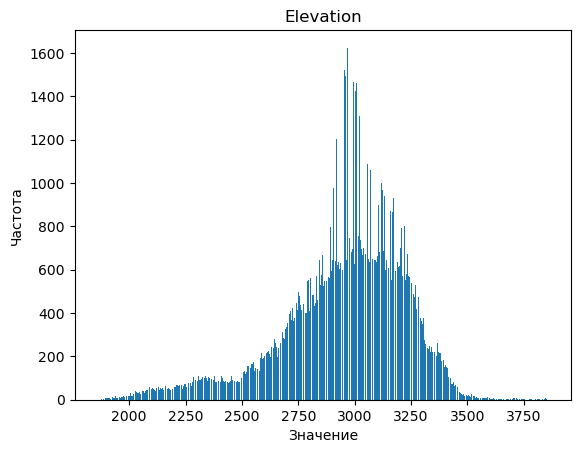

In [129]:
elevation_origin = ds_original["Elevation"].value_counts()
plt.bar(elevation_origin.index, elevation_origin.values )
plt.title('Elevation')
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

На графике видет дисбаланс количества значений. Максимальное количество сдвинуто вправо , однако слева имеется хвост с бОльшим количеством значений чем справа.

Продолжу визуализацию с Aspect

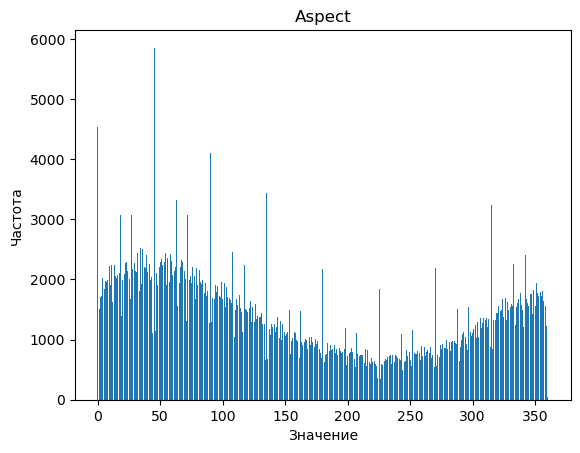

In [130]:
count = ds_original.Aspect.value_counts()
plt.bar(count.index, count.values)
plt.title("Aspect")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут видна интересная картина, распределение прям сильно не нормальное и больше похоже на равномерное. Также можно заметить некоторые резкие скачки частоты значений примерно каждые 40 единиц. Это можно связать с особенностью  параметра, однако я не очень понимаю , что он означает и как работает.

Продолжу визуализацию с Slope

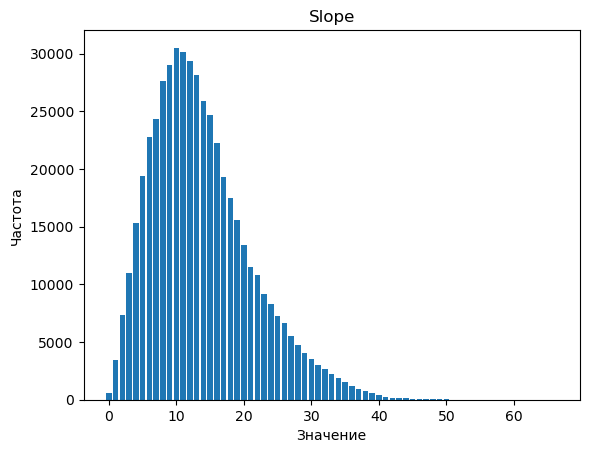

In [131]:
count = ds_original.Slope.value_counts()
plt.bar(count.index, count.values)
plt.title("Slope")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

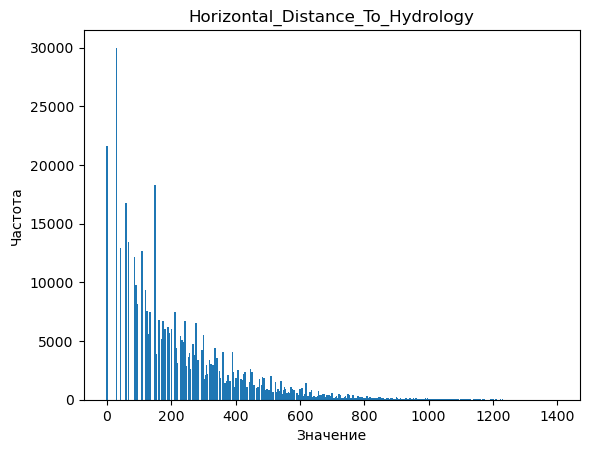

In [132]:
count = ds_original.Horizontal_Distance_To_Hydrology.value_counts()
plt.bar(count.index, count.values, width=5)
plt.title("Horizontal_Distance_To_Hydrology")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()


Тут мы можем видеть, что большая часть значний сконцентрирована в начале полосы значений. Также имеется очень тяжёлый хвост справа: значения там есть, но их количество минимальное. 

Продолжу визуализацию для Vertical_Distance_To_Hydrology

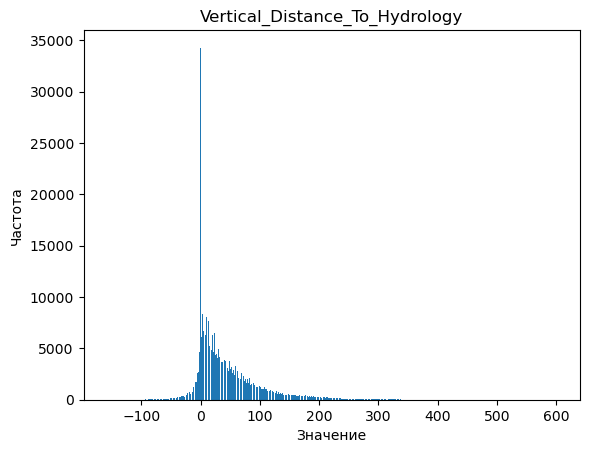

In [133]:
count = ds_original.Vertical_Distance_To_Hydrology.value_counts()
plt.bar(count.index, count.values)
plt.title("Vertical_Distance_To_Hydrology")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут видно, что большее число значений сконцентрировано около 0, что может говорить о том, что большинство лесов растёт на равнинах или около равнинных территориях, также мы можем видеть, что высота может быть как отрицательной, так и положительной (это говорит о разном расположении источников воды относительно поверхности)

Продолжу визуализацию для Horizontal_Distance_To_Roadways

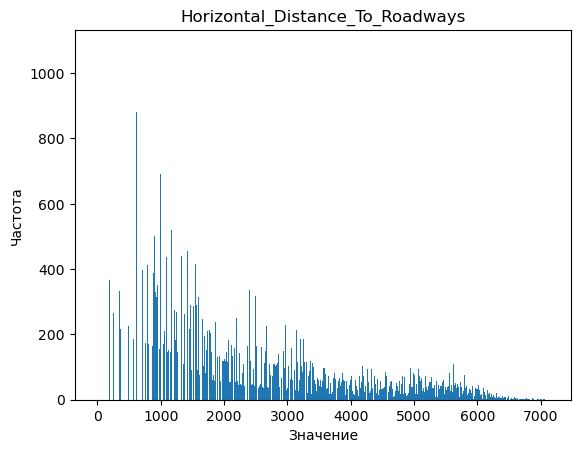

In [134]:
count = ds_original.Horizontal_Distance_To_Roadways.value_counts()
plt.bar(count.index, count.values, width=1)
plt.title("Horizontal_Distance_To_Roadways")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут мы также видим, что есть большой хвост справа , а основная масса значений сконцентрирована слева.

Продолжу виззуализацию для трёх видов Hillshade. Как я понял - это способ изображения рельефа с точки ззрения освещённости, так что значения этих полей стоит оценивать как степень освещённости участка в момент времени (чем больше число, тем больше освещённость)

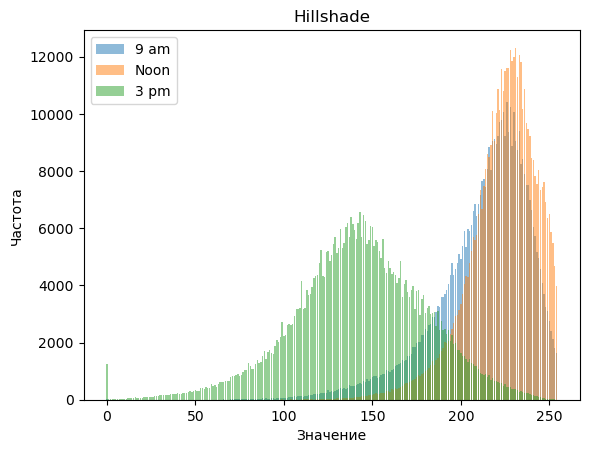

In [135]:
count = ds_original.Hillshade_9am.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_Noon.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_3pm.value_counts()
plt.bar(count.index, count.values,alpha = 0.5 )

plt.legend(["9 am", "Noon", "3 pm"])
plt.title("Hillshade")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Тут у нас виден явный выброс в значении 0 или около него. Предлагаю просто удалить данные, которые нахоядтся в этом значении. Вероятно, этот выброс получился из-за того, что были значения левее этого около 0-вого значения и их всех объединили в одно, а это вина сборщиков данных. 

In [136]:
print(count[count.index < 20].sort_index())

Hillshade_3pm
0     1266
1       14
2       15
3       15
4       18
5       18
6       24
7       28
8       20
9       31
10      38
11      23
12      49
13      58
14      44
15      61
16      78
17      66
18      67
19      71
Name: count, dtype: int64


In [137]:
ds_original.drop(index = ds_original[ds_original.Hillshade_3pm ==0].index, inplace=True)

Теперь проверим удалились ли данные корректно, построив гистограмму заново

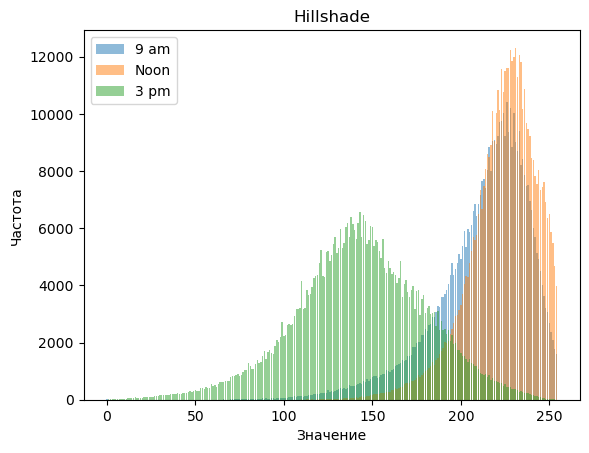

In [138]:
count = ds_original.Hillshade_9am.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_Noon.value_counts()
plt.bar(count.index, count.values, alpha = 0.5)
count = ds_original.Hillshade_3pm.value_counts()
plt.bar(count.index, count.values,alpha = 0.5 )

plt.legend(["9 am", "Noon", "3 pm"])
plt.title("Hillshade")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

In [139]:
ds_original.info()

<class 'pandas.DataFrame'>
Index: 504088 entries, 0 to 505353
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           504088 non-null  int64
 1   Aspect                              504088 non-null  int64
 2   Slope                               504088 non-null  int64
 3   Horizontal_Distance_To_Hydrology    504088 non-null  int64
 4   Vertical_Distance_To_Hydrology      504088 non-null  int64
 5   Horizontal_Distance_To_Roadways     504088 non-null  int64
 6   Hillshade_9am                       504088 non-null  int64
 7   Hillshade_Noon                      504088 non-null  int64
 8   Hillshade_3pm                       504088 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  504088 non-null  int64
 10  Wilderness_Area_0                   504088 non-null  int64
 11  Wilderness_Area_1                   504088 non-null  int64
 12  Wild

Теперь всё хорошо, хоть и количество данных уменьшилось(незначительно).

Поговорим в общем про все Hillshade. Они ведут себя в принципе логично: максимальные показания освещённости находяться в Noon, тогда как минимум в 3 pm.

Продолжу визуализацию с Horizontal_Distance_To_Fire_Points

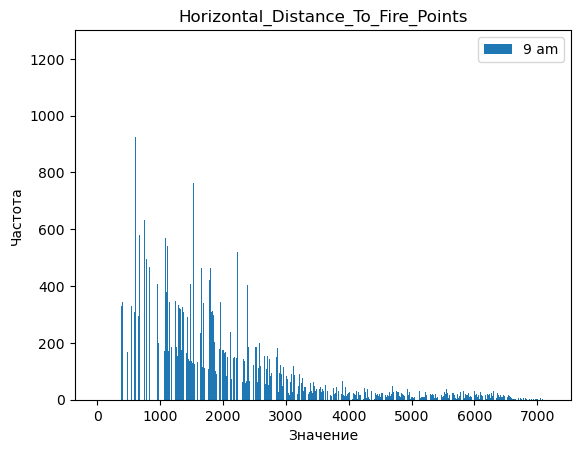

In [140]:
count = ds_original.Horizontal_Distance_To_Fire_Points.value_counts()
plt.bar(count.index, count.values )

plt.legend(["9 am", "Noon", "3 pm"])
plt.title("Horizontal_Distance_To_Fire_Points")
plt.ylabel('Частота')
plt.xlabel("Значение")
plt.show()

Теперь я мне предстоит визуализировать Wilderness_Area_x, которые переводятся как "дикость местности", и имеет бинарный формат. Я предлагаю по отдельности не визуализировать их (так как признаков 4, то я понятия не имею как они работают и что означают), а отобразить на гистограмме сразу все 1 колонки.

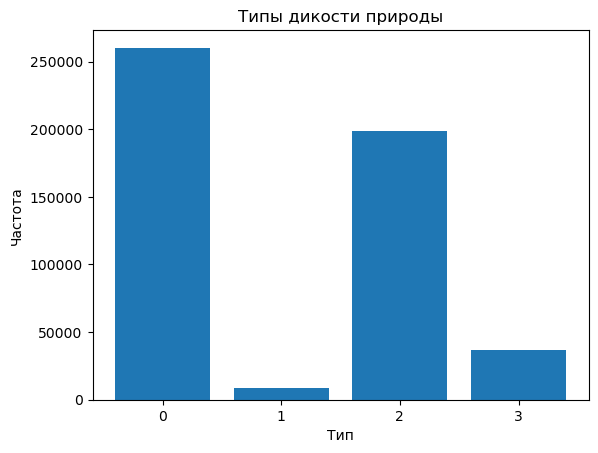

In [141]:
wilderness_area_x_count = np.zeros(4, dtype=np.int64)
for i in range(0,4):
    wilderness_area_x_count[i] = ds_original[f"Wilderness_Area_{i}"].sum()

plt.bar([0,1,2,3],wilderness_area_x_count)
plt.title("Типы дикости природы")
plt.xlabel("Тип")
plt.ylabel("Частота")
plt.xticks([0,1,2,3])
plt.show()

Тут можно увидеть, что почему-то первый и 4 тип дикости больше всего распространены, не знаю как это интерпретировать, но оно так есть. Продолжу визуализацию с Soil_Type_x и буду действовать точно также

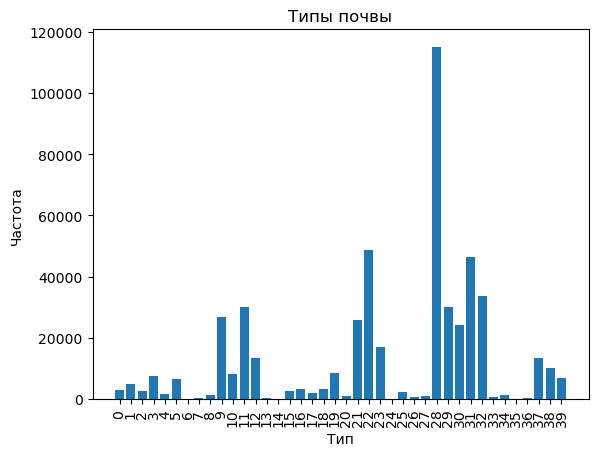

In [142]:
soil_type_x_count = np.zeros(40)
soil_types = np.arange(0,40)
for i in range(0, 40):
    soil_type_x_count[i] = ds_original[f"Soil_Type_{i}"].sum()

plt.bar(soil_types, soil_type_x_count)
plt.title("Типы почвы")
plt.xlabel("Тип")
plt.ylabel("Частота")
plt.xticks(soil_types, rotation = 90)
plt.show()

Мы можем видеть что этот параметр распределён неравномернно

Завершу одномерную визуализацию с последни столбиком Cover_Type

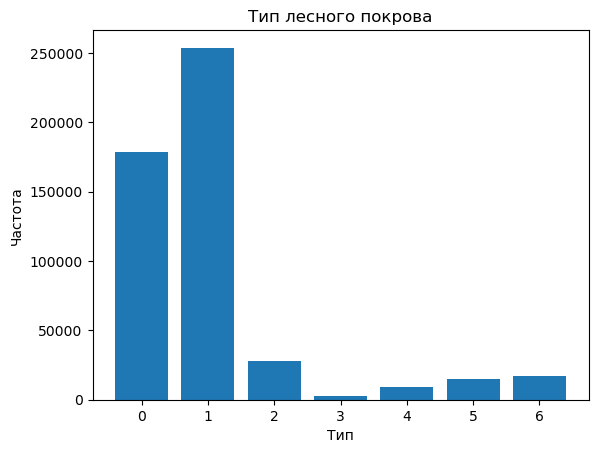

In [143]:
cover_type_counts = ds_original.Cover_Type.value_counts()
cover_type_counts.sort_index(inplace=True)

plt.bar(cover_type_counts.index, cover_type_counts.values)
plt.title("Тип лесного покрова")
plt.ylabel("Частота")
plt.xlabel("Тип")
plt.show()

Мне кажется мы видим весьма логичную картину - определённых типов лесного покрова всегда больше чем остальных, так что противоречия я не вижу.

Двумерная визуализация
-

Построю тепловую карту корреляции для признаков. Cчитать корреляцию по Soil_Type и Wildness_Type бесполезно, так как это бывшие категориальные признаки( как мне кажется ), так что их сключу

<Axes: >

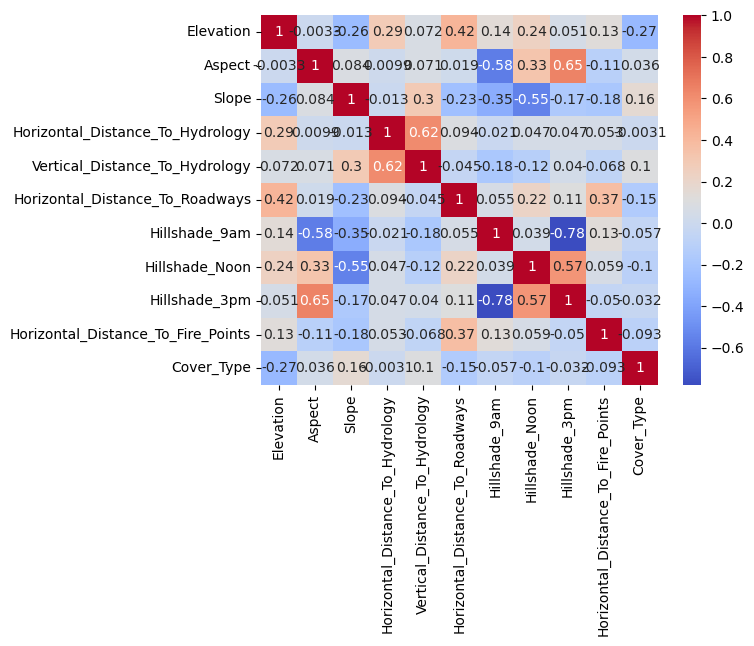

In [144]:
true_numeric_cols = ["Elevation","Aspect","Slope","Horizontal_Distance_To_Hydrology","Vertical_Distance_To_Hydrology","Horizontal_Distance_To_Roadways", "Hillshade_9am","Hillshade_Noon","Hillshade_3pm","Horizontal_Distance_To_Fire_Points", "Cover_Type" ]
corr_matrix = ds_original[true_numeric_cols].corr()
sns.heatmap(corr_matrix,annot=True,  cmap = 'coolwarm')

Тут мы видим почти полное отсутсвие корреляции с Cover_Type, только признаки Elavetion, Slope, Horizontal_Distance_To_Roadways, матрицу рассения построю только для них, так как с посмтройкой для всех мой ноутбук не справляется 

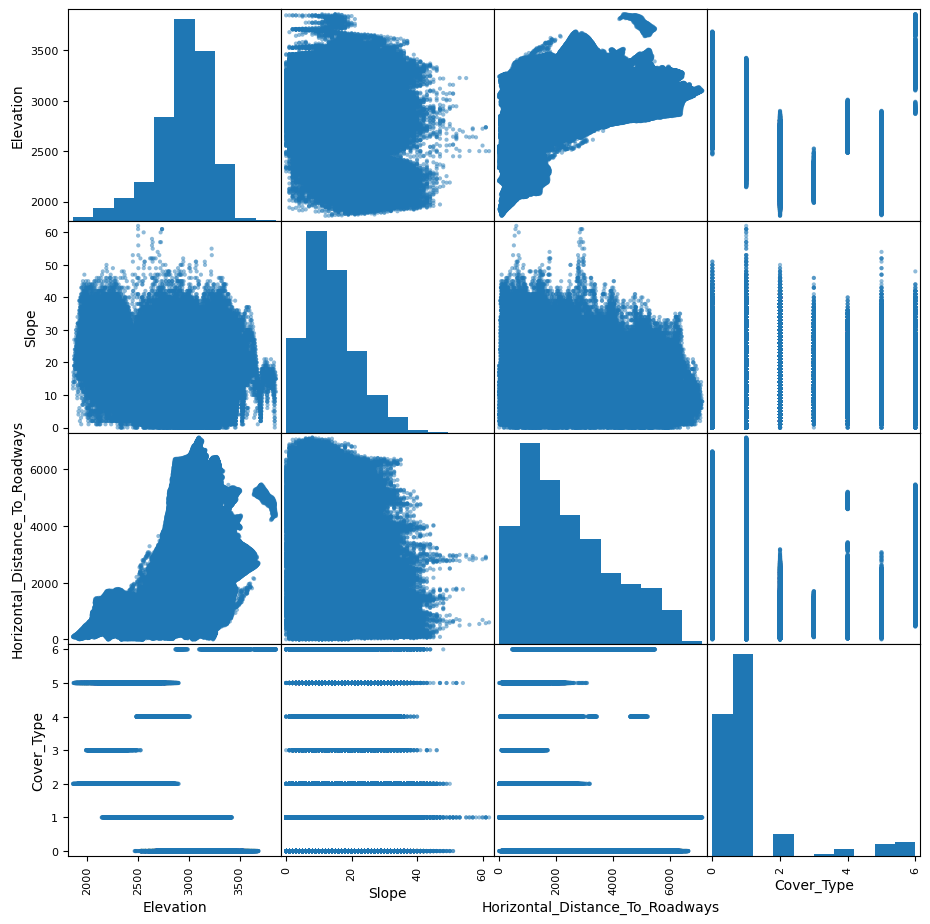

In [145]:
true_numeric_cols = ["Elevation", "Slope", "Horizontal_Distance_To_Roadways","Cover_Type"]
scatter_matrix(ds_original[true_numeric_cols], figsize=(11,11))
plt.show()

Тут корреляцию разглядеть сложно, так как значениц cover_type не много, можно построить следующий график и посмотреть

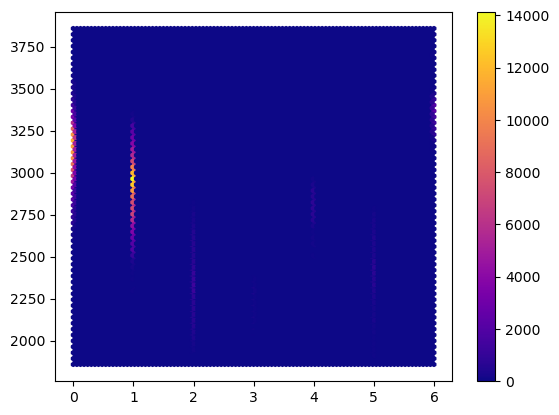

In [146]:
plt.hexbin(ds_original.Cover_Type, ds_original.Elevation, cmap='plasma' )
plt.colorbar()

Тут видно, что есть небольшая нелинейная зависимость, однако большинство значений сконцентрировано в значении 2. Выведу аналогичные графики для оставшихся признаков

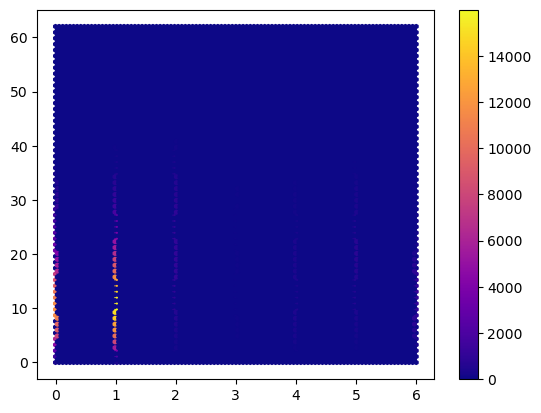

In [147]:
plt.hexbin(ds_original.Cover_Type, ds_original.Slope, cmap='plasma' )
plt.colorbar()

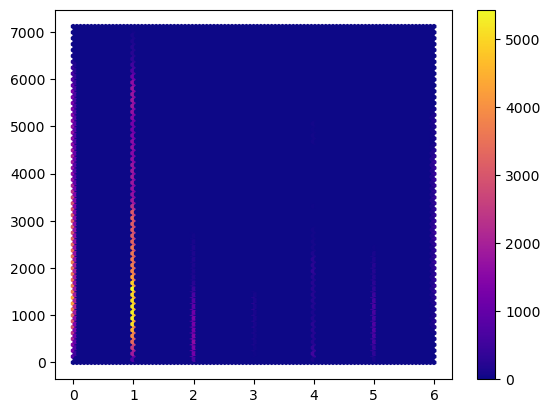

In [148]:
plt.hexbin(ds_original.Cover_Type, ds_original.Horizontal_Distance_To_Roadways, cmap='plasma' )
plt.colorbar()

Мне пока слодно что-то сказать, хочу попробовать сделать корреляционный анализ по Soil_type и Wildness_area. Для этого применю корреляцию Спиртмена, так как она не чувтсвительна к распределению

In [149]:
cols = ['Wilderness_Area_0', 'Wilderness_Area_1', 'Wilderness_Area_2', 'Wilderness_Area_3']
for col in cols:
    
    corr_coefficient, p_value = spearmanr(ds_original[col], ds_original['Cover_Type'])
    print(f"{col}: Spearman's ρ = {corr_coefficient:.3f} (p-value = {p_value:.4f})")

Wilderness_Area_0: Spearman's ρ = -0.221 (p-value = 0.0000)
Wilderness_Area_1: Spearman's ρ = -0.072 (p-value = 0.0000)
Wilderness_Area_2: Spearman's ρ = 0.028 (p-value = 0.0000)
Wilderness_Area_3: Spearman's ρ = 0.408 (p-value = 0.0000)


Тут мы можем видеть, что есть довольно сильная корреляция с Wildness_Area_3

In [150]:
wa_cols = [ f"Soil_Type_{x}" for x in range(0, 40)]
res = {}
for col in wa_cols:
    
    corr_coefficient, p_value = spearmanr(ds_original[col], ds_original['Cover_Type'])
    res[col] = corr_coefficient
    
sorted_dict = dict(sorted(res.items(), key=lambda x: x[1], reverse=True))
for val, i in sorted_dict.items():
    print(val, i)

    

Soil_Type_9 0.2823752710801973
Soil_Type_5 0.1579043650274892
Soil_Type_1 0.14758651086005228
Soil_Type_3 0.13726672315779606
Soil_Type_0 0.11706648291224359
Soil_Type_2 0.10662933944382524
Soil_Type_4 0.08796321699903721
Soil_Type_16 0.08630239151529058
Soil_Type_10 0.08044160855090607
Soil_Type_11 0.06417438564607254
Soil_Type_12 0.06362946422285663
Soil_Type_13 0.04399372634083913
Soil_Type_36 0.043878080262079414
Soil_Type_34 0.04172370041049927
Soil_Type_17 0.031123516246530685
Soil_Type_29 0.0213183087316239
Soil_Type_25 0.01872636950910259
Soil_Type_33 0.01761720516161623
Soil_Type_27 0.01501520014288768
Soil_Type_35 0.014911889029615906
Soil_Type_38 0.01368371633544824
Soil_Type_37 0.011338441304925244
Soil_Type_15 0.0100376713419922
Soil_Type_26 0.00904570367873208
Soil_Type_8 0.008256476564984178
Soil_Type_6 0.005802030294656717
Soil_Type_14 0.0041887951357541696
Soil_Type_24 0.0005661617663078619
Soil_Type_7 0.00018701430508206548
Soil_Type_39 -0.010108676533368686
Soil_Type

Тут мы видим, что наилучшая корреляцию достигает Soil_Type_9, Soil_Type_21, Soil_Type_22

Логистическая регрессия
-

Начну с логичтической регрессии без изменения датасета. Только начну с раделением по выборкам

In [151]:
ds_original_learn, ds_original_control = train_test_split(ds_original, test_size=0.1)
ds_original_control, ds_original_test = train_test_split(ds_original_control, test_size= 0.5)

In [152]:
Y_original_learn = ds_original_learn["Cover_Type"]
Y_original_control = ds_original_control["Cover_Type"]
Y_original_test = ds_original_test["Cover_Type"]

X_original_learn = ds_original_learn[ds_original_learn.columns.difference(['Cover_Type'])]
X_original_control = ds_original_control[ds_original_control.columns.difference(['Cover_Type'])]
X_original_test = ds_original_test[ds_original_test.columns.difference(['Cover_Type'])]


Теперь будет обучать модель, так как классов много - буду использовать гиперпараметр multi_class = "multinimial"

In [153]:
log_origin = LogisticRegression( solver = "lbfgs", max_iter=300, C=1)
log_origin.fit(X_original_learn, Y_original_learn)

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Тут мы видим, что модель не сходится даже при 300 операциях, мне кажется, что это из-за того, что данные немасшабированные, так что ничего делать сейчас не буду. Выведу метрики полученной модели

In [154]:
y_pred_origin = log_origin.predict(X_original_learn)
print("Сбалансированная точность модели log_origin на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели log_origin на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели log_origin на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1


Сбалансированная точность модели log_origin на обучающей выборке:
0.2943298909778157 

Confusion_matrix модели log_origin на обучающей выборке:
[[ 99993  60048    127      0      0      0    502]
 [ 39169 184351   4218      0      3    291    252]
 [    25   8995  15135      0     39    900      7]
 [     0    107   2302      0      3      2      0]
 [   245   7925    108      0      0      1      6]
 [    59   6950   6087      0     12    263      5]
 [ 13969   1459      0      0      0      0    121]] 

F1 метрики для модели log_origin на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.28532796509233094
F1 метрики по отдельным классам: 
Cover_Type_0: 0.6366
Cover_Type_1: 0.7402
Cover_Type_2: 0.5703
Cover_Type_3: 0.0000
Cover_Type_4: 0.0000
Cover_Type_5: 0.0355
Cover_Type_6: 0.0147


Мы видим крайне печальные результаты, точность составляется всего 0.29, а f1 score по некоторым классам вообще 0. Попоробую исправить ситуацию, использовав class_weigth = balanced и усилю С регуляризацию

In [155]:
log_origin = LogisticRegression( solver = "lbfgs", max_iter=500, C=0.1, class_weight="balanced")
log_origin.fit(X_original_learn, Y_original_learn)

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [156]:
y_pred_origin = log_origin.predict(X_original_learn)
print("Сбалансированная точность модели log_origin на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели log_origin на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели log_origin на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1


Сбалансированная точность модели log_origin на обучающей выборке:
0.556063881934569 

Confusion_matrix модели log_origin на обучающей выборке:
[[66055 31895    63    47 17035  1474 44101]
 [46849 96197  5335   492 55798 10957 12656]
 [  364   466  9765  4933  2383  7171    19]
 [    0     0   325  1947     8   134     0]
 [  260  1351   319    25  5263   917   150]
 [  644  1151  3081  1594  1073  5814    19]
 [ 2722   234     0     0   240     0 12353]] 

F1 метрики для модели log_origin на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.3564133575146455
F1 метрики по отдельным классам: 
Cover_Type_0: 0.4760
Cover_Type_1: 0.5351
Cover_Type_2: 0.4440
Cover_Type_3: 0.3400
Cover_Type_4: 0.1168
Cover_Type_5: 0.2918
Cover_Type_6: 0.2912


Чтож, мне удалось поправить ситуацию, однако не скажу, что модель хороша. Мне кажется, это лучший результат, которого я могу сейчас добиться, так что хочу проверить модель на контрольной выборке

In [157]:
y_pred_origin_control = log_origin.predict(X_original_control)
print("Сбалансированная точность модели log_origin на контрольной выборке:")
print(balanced_accuracy_score(Y_original_control, y_pred_origin_control), "\n")
print("Confusion_matrix модели log_origin на контрольной выборке:")
print(confusion_matrix(Y_original_control, y_pred_origin_control), "\n")
print("F1 метрики для модели log_origin на контрольной выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_control, y_pred_origin_control, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_control, y_pred_origin_control, average=None)
k=1
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1


Сбалансированная точность модели log_origin на контрольной выборке:
0.5696359150931365 

Confusion_matrix модели log_origin на контрольной выборке:
[[3667 1764    4    4  912   77 2413]
 [2654 5476  282   19 3070  567  722]
 [  16   26  545  279  143  365    2]
 [   0    0   17  130    1    7    0]
 [  20   66    9    2  322   42    4]
 [  37   69  175   83   60  317    0]
 [ 155   12    0    0    9    0  660]] 

F1 метрики для модели log_origin на контрольной выборке:
F1 по всей выборке: 
Macro f1:  0.3673939401763663
F1 метрики по отдельным классам: 
Cover_Type_1: 0.4765
Cover_Type_2: 0.5421
Cover_Type_3: 0.4527
Cover_Type_4: 0.3869
Cover_Type_5: 0.1293
Cover_Type_6: 0.2996
Cover_Type_7: 0.2847


На удивление модель показала себя лучше, чем на обучающей выборке, перейду дальше к созданию нейронной модели

In [169]:
neir_origin1 = models.Sequential()
neir_origin1.add(layers.Dense(54, activation='relu', input_shape = (54,)))
neir_origin1.add(layers.Dense(120, activation='relu'))
neir_origin1.add(layers.Dense(60, activation='relu'))
neir_origin1.add(layers.Dense(7, activation='softmax'))
neir_origin1.summary()

/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 54)             │         2,970 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 120)            │         6,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 60)             │         7,260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 7)              │           427 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,257 (67.41 KB)

 Trainable params: 17,257 (67.41 KB)

 Non-trainable params: 0 (0.00 B)

In [170]:


neir_origin1.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics= ["accuracy"])
callbacks_list = [
    callbacks.EarlyStopping(
        monitor = 'val_loss',
        patience=25,
    ),
    callbacks.ModelCheckpoint(
        filepath="Neir_origin1.h5",
        monitor='val_accuracy',
        save_best_only=True,
    ),
    callbacks.ReduceLROnPlateau(
        monitor = 'val_loss',
        factor = 0.25,
        patience=10,
    )
]

neir1 = neir_origin1.fit(X_original_learn, Y_original_learn, validation_data=(X_original_control, Y_original_control), callbacks = callbacks_list, epochs=100, batch_size=128)

Epoch 1/100
3524/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5321 - loss: 7.7148

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.5910 - loss: 2.3350 - val_accuracy: 0.6123 - val_loss: 1.0567 - learning_rate: 0.0010
Epoch 2/100
3510/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6735 - loss: 0.8179

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6872 - loss: 0.7672 - val_accuracy: 0.7195 - val_loss: 0.6793 - learning_rate: 0.0010
Epoch 3/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7213 - loss: 0.6534 - val_accuracy: 0.7170 - val_loss: 0.6764 - learning_rate: 0.0010
Epoch 4/100
3505/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7376 - loss: 0.6100

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7406 - loss: 0.6017 - val_accuracy: 0.7500 - val_loss: 0.5778 - learning_rate: 0.0010
Epoch 5/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7573 - loss: 0.5622 - val_accuracy: 0.7436 - val_loss: 0.5714 - learning_rate: 0.0010
Epoch 6/100
3522/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7692 - loss: 0.5359

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.7713 - loss: 0.5297 - val_accuracy: 0.7794 - val_loss: 0.5082 - learning_rate: 0.0010
Epoch 7/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7835 - loss: 0.5016 - val_accuracy: 0.7674 - val_loss: 0.5310 - learning_rate: 0.0010
Epoch 8/100
3535/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7913 - loss: 0.4838

...

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8993 - loss: 0.2452 - val_accuracy: 0.8955 - val_loss: 0.2572 - learning_rate: 2.5000e-04
Epoch 79/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8989 - loss: 0.2457 - val_accuracy: 0.8940 - val_loss: 0.2602 - learning_rate: 2.5000e-04
Epoch 80/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8993 - loss: 0.2441 - val_accuracy: 0.8940 - val_loss: 0.2626 - learning_rate: 2.5000e-04
Epoch 81/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8996 - loss: 0.2447 - val_accuracy: 0.8826 - val_loss: 0.2844 - learning_rate: 2.5000e-04
Epoch 82/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.8997 - loss: 0.2437 - val_accuracy: 0.8926 - val_loss: 0.2587 - learning_rate: 2.5000e-04
Epoch 83/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8995 - loss: 0.2437 - val_accuracy: 0.8736 - val_loss: 0.3088 - learning_rate: 2.5000e-04
Epoch 84/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9000 - loss: 0.2428 - val_accuracy: 0.8963 - val_loss: 0.2526 - learning_rate: 2.5000e-04
Epoch 86/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9004 - loss: 0.2428 - val_accuracy: 0.8918 - val_loss: 0.2687 - learning_rate: 2.5000e-04
Epoch 87/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9004 - loss: 0.2424 - val_accuracy: 0.8932 - val_loss: 0.2605 - learning_rate: 2.5000e-04
Epoch 88/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9009 - loss: 0.2412 - val_accuracy: 0.8958 - val_loss: 0.2581 - learning_rate: 2.5000e-04
Epoch 89/100
3518/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9007 - loss: 0.2412

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9004 - loss: 0.2422 - val_accuracy: 0.8976 - val_loss: 0.2505 - learning_rate: 2.5000e-04
Epoch 90/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9005 - loss: 0.2417 - val_accuracy: 0.8960 - val_loss: 0.2558 - learning_rate: 2.5000e-04
Epoch 91/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9014 - loss: 0.2402 - val_accuracy: 0.8927 - val_loss: 0.2595 - learning_rate: 2.5000e-04
Epoch 92/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9014 - loss: 0.2407 - val_accuracy: 0.8969 - val_loss: 0.2551 - learning_rate: 2.5000e-04
Epoch 93/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9009 - loss: 0.2409 - val_accuracy: 0.8930 - val_loss: 0.2641 - learning_rate: 2.5000e-04
Epoch 94/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9015 - loss: 0.2410 - val_accuracy: 0.8947 - val_loss: 0.2586 - learning_rate: 2.5000e-04
Epoch 95/100
3527/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/st

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9017 - loss: 0.2399 - val_accuracy: 0.8994 - val_loss: 0.2505 - learning_rate: 2.5000e-04
Epoch 96/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9017 - loss: 0.2393 - val_accuracy: 0.8964 - val_loss: 0.2554 - learning_rate: 2.5000e-04
Epoch 97/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9021 - loss: 0.2395 - val_accuracy: 0.8993 - val_loss: 0.2516 - learning_rate: 2.5000e-04
Epoch 98/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9021 - loss: 0.2387 - val_accuracy: 0.8942 - val_loss: 0.2590 - learning_rate: 2.5000e-04
Epoch 99/100
3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9023 - loss: 0.2388 - val_accuracy: 0.8927 - val_loss: 0.2612 - learning_rate: 2.5000e-04
Epoch 100/100
3501/3545 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9100 - loss: 0.2208

3545/3545 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9110 - loss: 0.2187 - val_accuracy: 0.9043 - val_loss: 0.2378 - learning_rate: 6.2500e-05


Я решил изначально взять модель, оченб похожую на представленную в материалах лекций, как-то пытаться усоверщшенствовать её я буду пытаться на лучшем наборе данных-модель, если это будет нейронная сеть. А теперь загрузим модель из файла и посмотрим на её метрики на обучающей и тестовой выборке.

In [186]:
best_nier_origin1 = load_model("Neir_origin1.h5")
y_pred_origin = best_nier_origin1.predict(X_original_learn)
y_pred_origin = np.argmax(y_pred_origin, axis=1)


14178/14178 ━━━━━━━━━━━━━━━━━━━━ 7s 523us/step


In [187]:

print("Сбалансированная точность модели  на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели  на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1

Сбалансированная точность модели  на обучающей выборке:
0.865485519855864 

Confusion_matrix модели на обучающей выборке:
[[142630  17136      8      0    159     36    701]
 [ 11954 214516    382      4    986    367     75]
 [     8    419  23425    181     59   1009      0]
 [     0      0    318   1964      0    132      0]
 [   130   1923    133      0   6058     41      0]
 [    69    455   1268     87     48  11449      0]
 [  1364    235      0      0      2      0  13948]] 

F1 метрики для модели  на обучающей выборке:
F1 по всей выборке: 
Macro f1:  0.8803382473365348
F1 метрики по отдельным классам: 
Cover_Type_0: 0.9004
Cover_Type_1: 0.9267
Cover_Type_2: 0.9252
Cover_Type_3: 0.8447
Cover_Type_4: 0.7768
Cover_Type_5: 0.8670
Cover_Type_6: 0.9215


Тут мы видим огромный прогресс!! У нас выявляются все классы и довольно неплохо, я бы сказал. Проверю как модель поведёт себя на контрольной выборке

In [ ]:
y_pred_origin_control = best_nier_origin1.predict(X_original_control)
y_pred_origin_control = np.argmax(y_pred_origin_control, axis=1)

788/788 ━━━━━━━━━━━━━━━━━━━━ 0s 479us/step


In [ ]:
print("Сбалансированная точность модели log_origin на обучающей выборке:")
print(balanced_accuracy_score(Y_original_learn, y_pred_origin), "\n")
print("Confusion_matrix модели log_origin на обучающей выборке:")
print(confusion_matrix(Y_original_learn, y_pred_origin), "\n")
print("F1 метрики для модели log_origin на обучающей выборке:")
print("F1 по всей выборке: ")
print("Macro f1: ", f1_score(Y_original_learn, y_pred_origin, average = "macro"))
print("F1 метрики по отдельным классам: ")
f1_per_class = f1_score(Y_original_learn, y_pred_origin, average=None)
k=0
for  f1 in f1_per_class:
    print(f"Cover_Type_{k}: {f1:.4f}")
    k+=1
